# 03 — OvaSense-ML: Hyperparameter Optimization, Threshold Tuning, Probability Calibration & Clinical Screening Validation

**Project**: OvaSense Standalone PCOS Risk-Screening Machine Learning  
**Phase**: 3 — Model Optimization & Clinical Screening Validation (Audited Final Version)  
**Evaluation Date**: August 31, 2026  
**Primary Objective**: Optimize and calibrate OvaSense specifically as an **early non-invasive PCOS risk-screening tool** using the 16 patient-reportable features, prioritizing **Sensitivity/Recall** and **PR-AUC** while preserving specificity, and validating holdout generalization on the locked test set ($N=109$).

---

### Strict Methodological Safeguards Maintained:
1. **Zero Data Leakage**: All hyperparameter searches (`GridSearchCV`, `RandomizedSearchCV`), out-of-fold probability estimations, probability calibrations, and threshold scans are performed **strictly on the 432-patient training set** using 5-fold Stratified Cross-Validation (`random_state=42`).
2. **Single-Pass Test Evaluation**: The locked holdout test set (`data/processed/test.csv`, $N=109$) is evaluated **strictly once** after the final model architecture and screening threshold are locked.
3. **No Invasive Biomarkers**: Model inputs are restricted to 16 non-invasive, patient-reportable symptoms, menstrual history, anthropometrics, and lifestyle factors (zero pelvic ultrasound follicle counts, zero hormonal assays).
4. **Evidence-Based Model Selection**: Final model selection is driven by comprehensive cross-validation evidence (PR-AUC, ROC-AUC, Sensitivity, Specificity, Brier score, and threshold behavior) rather than default algorithmic bias.


## 1. Environment & Library Initialization

In [5]:
import os
import sys
import json
import time
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report,
    brier_score_loss
)
import shap

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 300

# Repository root detection
current_dir = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..')) if os.path.basename(current_dir).lower() == 'notebooks' else os.path.abspath(current_dir)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.preprocessing import (
    RAW_CORE_FEATURES,
    FEATURE_NAME_MAP,
    TARGET_COL,
    ID_COLS,
    build_preprocessor
)

FIGURES_DIR = os.path.join(PROJECT_ROOT, 'reports', 'figures')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print("Dependencies loaded successfully.")

Project Root: c:\Users\hp\Desktop\Ovasense-ML
Dependencies loaded successfully.


## 2. Load Processed Datasets & Verification

We load the pre-split, leak-free datasets generated in Phase 2:
* **Training Set**: `data/processed/train.csv` ($N=432$, 141 PCOS / 291 Non-PCOS, 32.64% prevalence)
* **Locked Test Set**: `data/processed/test.csv` ($N=109$, 36 PCOS / 73 Non-PCOS, 33.03% prevalence)


In [6]:
train_df = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', 'processed', 'train.csv'))
test_df = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', 'processed', 'test.csv'))

X_train = train_df[RAW_CORE_FEATURES].copy()
y_train = train_df[TARGET_COL].values

X_test = test_df[RAW_CORE_FEATURES].copy()
y_test = test_df[TARGET_COL].values

print(f"Training Set : {X_train.shape[0]} samples, {X_train.shape[1]} features | PCOS (+): {y_train.sum()} ({y_train.mean():.2%}) | Non-PCOS (-): {len(y_train)-y_train.sum()}")
print(f"Locked Test  : {X_test.shape[0]} samples, {X_test.shape[1]} features | PCOS (+): {y_test.sum()} ({y_test.mean():.2%}) | Non-PCOS (-): {len(y_test)-y_test.sum()}")


Training Set : 432 samples, 16 features | PCOS (+): 141 (32.64%) | Non-PCOS (-): 291
Locked Test  : 109 samples, 16 features | PCOS (+): 36 (33.03%) | Non-PCOS (-): 73


## 3. Step 1 — Hyperparameter Optimization (Stratified 5-Fold CV)

We systematically tune four candidate model families on the 432-patient training set using 5-fold Stratified Cross-Validation (`random_state=42`) with primary optimization objective **Average Precision (PR-AUC)**:
1. **Logistic Regression**
2. **Random Forest**
3. **Extra Trees**
4. **HistGradientBoosting**


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuning_configs = {
    'Logistic Regression': {
        'base_pipe': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=True)),
            ('classifier', LogisticRegression(random_state=42, max_iter=1000))
        ]),
        'search_type': 'grid',
        'params': [
            {
                'classifier__C': [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0],
                'classifier__penalty': ['l2'],
                'classifier__solver': ['lbfgs'],
                'classifier__class_weight': [None, 'balanced', {0: 1.0, 1: 1.5}, {0: 1.0, 1: 2.0}]
            },
            {
                'classifier__C': [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0],
                'classifier__penalty': ['l1'],
                'classifier__solver': ['liblinear'],
                'classifier__class_weight': [None, 'balanced', {0: 1.0, 1: 1.5}, {0: 1.0, 1: 2.0}]
            }
        ]
    },
    'Random Forest': {
        'base_pipe': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=False)),
            ('classifier', RandomForestClassifier(random_state=42))
        ]),
        'search_type': 'random',
        'n_iter': 25,
        'params': {
            'classifier__n_estimators': [100, 150, 200],
            'classifier__max_depth': [None, 3, 5, 7, 10],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__max_features': ['sqrt', 'log2', 0.5],
            'classifier__class_weight': [None, 'balanced', 'balanced_subsample', {0: 1.0, 1: 1.5}, {0: 1.0, 1: 2.0}]
        }
    },
    'Extra Trees': {
        'base_pipe': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=False)),
            ('classifier', ExtraTreesClassifier(random_state=42))
        ]),
        'search_type': 'random',
        'n_iter': 25,
        'params': {
            'classifier__n_estimators': [100, 150, 200],
            'classifier__max_depth': [None, 3, 5, 7, 10],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__max_features': ['sqrt', 'log2', 0.5],
            'classifier__class_weight': [None, 'balanced', 'balanced_subsample', {0: 1.0, 1: 1.5}, {0: 1.0, 1: 2.0}]
        }
    },
    'HistGradientBoosting': {
        'base_pipe': Pipeline([
            ('preprocessor', build_preprocessor(scale_numeric=False)),
            ('classifier', HistGradientBoostingClassifier(random_state=42))
        ]),
        'search_type': 'random',
        'n_iter': 20,
        'params': {
            'classifier__learning_rate': [0.03, 0.05, 0.1],
            'classifier__max_iter': [40, 60, 80],
            'classifier__max_leaf_nodes': [15, 31],
            'classifier__max_depth': [None, 3, 5],
            'classifier__min_samples_leaf': [10, 20],
            'classifier__l2_regularization': [0.0, 1.0, 5.0],
            'classifier__class_weight': [None, 'balanced']
        }
    }
}

best_tuned_pipelines = {}
tuning_summary = {}

for name, cfg in tuning_configs.items():
    t0 = time.time()
    if cfg['search_type'] == 'grid':
        search = GridSearchCV(
            cfg['base_pipe'],
            param_grid=cfg['params'],
            scoring='average_precision',
            cv=cv,
            n_jobs=1,
            refit=True
        )
    else:
        search = RandomizedSearchCV(
            cfg['base_pipe'],
            param_distributions=cfg['params'],
            n_iter=cfg['n_iter'],
            scoring='average_precision',
            cv=cv,
            random_state=42,
            n_jobs=1,
            refit=True
        )
    search.fit(X_train, y_train)
    duration = time.time() - t0
    best_pipe = search.best_estimator_
    best_tuned_pipelines[name] = best_pipe
    tuning_summary[name] = {
        'best_params': search.best_params_,
        'best_score_prauc': float(search.best_score_),
        'search_time_sec': float(duration)
    }
    print(f"[{name}] Best CV PR-AUC: {search.best_score_:.4f} ({duration:.2f}s)")
    print(f"  Best Parameters: {search.best_params_}\n")


[Logistic Regression] Best CV PR-AUC: 0.8137 (45.12s)
  Best Parameters: {'classifier__C': 0.1, 'classifier__class_weight': {0: 1.0, 1: 1.5}, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

[Random Forest] Best CV PR-AUC: 0.8214 (92.83s)
  Best Parameters: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10, 'classifier__class_weight': {0: 1.0, 1: 2.0}}

[Extra Trees] Best CV PR-AUC: 0.8307 (54.55s)
  Best Parameters: {'classifier__n_estimators': 150, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 7, 'classifier__class_weight': 'balanced_subsample'}

[HistGradientBoosting] Best CV PR-AUC: 0.8115 (29.97s)
  Best Parameters: {'classifier__min_samples_leaf': 10, 'classifier__max_leaf_nodes': 15, 'classifier__max_iter': 60, 'classifier__max_depth': 3, 'classifier__learning_rate

## 4. Comprehensive Cross-Validation Performance Comparison

We compute fold-by-fold cross-validated metrics (PR-AUC, ROC-AUC, Sensitivity, Specificity, Precision, F1, Accuracy, Brier score) and extract out-of-fold (OOF) predicted probabilities $\hat{p}_i$ for every patient in the training set.


In [8]:
def evaluate_cv_detailed(pipeline, X, y, cv_splitter):
    fold_metrics = {
        'roc_auc': [], 'pr_auc': [], 'sensitivity': [], 'specificity': [],
        'precision': [], 'f1': [], 'accuracy': [], 'brier': []
    }
    oof_probs = np.zeros(len(X))
    oof_preds = np.zeros(len(X))
    
    for fold, (train_idx, val_idx) in enumerate(cv_splitter.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y[train_idx]
        X_va, y_val = X.iloc[val_idx], y[val_idx]
        
        clf = clone(pipeline)
        clf.fit(X_tr, y_tr)
        val_probs = clf.predict_proba(X_va)[:, 1]
        val_preds = (val_probs >= 0.50).astype(int)
        
        oof_probs[val_idx] = val_probs
        oof_preds[val_idx] = val_preds
        
        fold_metrics['roc_auc'].append(roc_auc_score(y_val, val_probs))
        fold_metrics['pr_auc'].append(average_precision_score(y_val, val_probs))
        fold_metrics['sensitivity'].append(recall_score(y_val, val_preds, zero_division=0))
        
        cm = confusion_matrix(y_val, val_preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        fold_metrics['specificity'].append(spec)
        fold_metrics['precision'].append(precision_score(y_val, val_preds, zero_division=0))
        fold_metrics['f1'].append(f1_score(y_val, val_preds, zero_division=0))
        fold_metrics['accuracy'].append(accuracy_score(y_val, val_preds))
        fold_metrics['brier'].append(brier_score_loss(y_val, val_probs))
        
    return {
        'roc_auc_mean': float(np.mean(fold_metrics['roc_auc'])),
        'roc_auc_std': float(np.std(fold_metrics['roc_auc'])),
        'pr_auc_mean': float(np.mean(fold_metrics['pr_auc'])),
        'pr_auc_std': float(np.std(fold_metrics['pr_auc'])),
        'sensitivity_mean': float(np.mean(fold_metrics['sensitivity'])),
        'sensitivity_std': float(np.std(fold_metrics['sensitivity'])),
        'specificity_mean': float(np.mean(fold_metrics['specificity'])),
        'specificity_std': float(np.std(fold_metrics['specificity'])),
        'precision_mean': float(np.mean(fold_metrics['precision'])),
        'precision_std': float(np.std(fold_metrics['precision'])),
        'f1_mean': float(np.mean(fold_metrics['f1'])),
        'f1_std': float(np.std(fold_metrics['f1'])),
        'accuracy_mean': float(np.mean(fold_metrics['accuracy'])),
        'accuracy_std': float(np.std(fold_metrics['accuracy'])),
        'brier_mean': float(np.mean(fold_metrics['brier'])),
        'brier_std': float(np.std(fold_metrics['brier'])),
        'oof_probs': oof_probs,
        'fold_metrics': fold_metrics
    }

cv_evaluations = {name: evaluate_cv_detailed(pipe, X_train, y_train, cv) for name, pipe in best_tuned_pipelines.items()}

cv_table = pd.DataFrame([
    {
        'Model Family': name,
        'CV PR-AUC': f"{ev['pr_auc_mean']:.4f} ± {ev['pr_auc_std']:.4f}",
        'CV ROC-AUC': f"{ev['roc_auc_mean']:.4f} ± {ev['roc_auc_std']:.4f}",
        'CV Sensitivity (t=0.50)': f"{ev['sensitivity_mean']:.2%} ± {ev['sensitivity_std']:.2%}",
        'CV Specificity (t=0.50)': f"{ev['specificity_mean']:.2%} ± {ev['specificity_std']:.2%}",
        'CV Precision (t=0.50)': f"{ev['precision_mean']:.2%} ± {ev['precision_std']:.2%}",
        'CV F1-Score (t=0.50)': f"{ev['f1_mean']:.4f} ± {ev['f1_std']:.4f}",
        'CV Brier Score': f"{ev['brier_mean']:.4f} ± {ev['brier_std']:.4f}"
    } for name, ev in cv_evaluations.items()
])

display(cv_table)


,Model Family,CV PR-AUC,CV ROC-AUC,CV Sensitivity (t=0.50),CV Specificity (t=0.50),CV Precision (t=0.50),CV F1-Score (t=0.50),CV Brier Score
0,Logistic Regression,0.8137 ± 0.0177,0.8732 ± 0.0106,73.08% ± 5.15%,86.94% ± 1.41%,73.09% ± 1.33%,0.7299 ± 0.0255,0.1304 ± 0.0037
1,Random Forest,0.8214 ± 0.0266,0.8823 ± 0.0151,75.96% ± 6.12%,85.91% ± 2.54%,72.44% ± 2.95%,0.7400 ± 0.0333,0.1298 ± 0.0049
2,Extra Trees,0.8307 ± 0.0143,0.8911 ± 0.0175,79.46% ± 5.12%,83.83% ± 2.86%,70.56% ± 4.05%,0.7467 ± 0.0390,0.1284 ± 0.0079
3,HistGradientBoosting,0.8115 ± 0.0356,0.8673 ± 0.0308,79.48% ± 5.45%,85.21% ± 2.84%,72.42% ± 3.69%,0.7566 ± 0.0343,0.1436 ± 0.0098


## 5. Step 2 & 3 — Fine-Grained Threshold Optimization ($t \in [0.05, 0.95]$)

We scan 91 threshold points ($0.05$ to $0.95$, step $0.01$) across training out-of-fold probabilities to evaluate operational trade-offs for early risk screening.


In [9]:
thresholds = np.arange(0.05, 0.96, 0.01)
threshold_dfs = {}

for name, ev in cv_evaluations.items():
    oof_p = ev['oof_probs']
    records = []
    for t in thresholds:
        preds = (oof_p >= t).astype(int)
        cm = confusion_matrix(y_train, preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
        f1 = 2 * (prec * sens) / (prec + sens) if (prec + sens) > 0 else 0.0
        acc = (tp + tn) / len(y_train)
        fnr = 1.0 - sens
        fpr = 1.0 - spec
        
        records.append({
            'threshold': round(float(t), 2),
            'sensitivity': sens,
            'specificity': spec,
            'precision': prec,
            'npv': npv,
            'f1': f1,
            'accuracy': acc,
            'fnr': fnr,
            'fpr': fpr,
            'tp': int(tp),
            'fp': int(fp),
            'tn': int(tn),
            'fn': int(fn)
        })
    df_thresh = pd.DataFrame(records)
    threshold_dfs[name] = df_thresh

# Display key operating points across all models
op_records = []
for name, df_thresh in threshold_dfs.items():
    row_50 = df_thresh[df_thresh['threshold'] == 0.50].iloc[0]
    row_f1 = df_thresh.loc[df_thresh['f1'].idxmax()]
    sens_85 = df_thresh[df_thresh['sensitivity'] >= 0.85]
    row_85 = sens_85.sort_values(by=['specificity', 'f1'], ascending=False).iloc[0] if not sens_85.empty else None
    
    op_records.append({
        'Model': name,
        'Point': 'Default (t=0.50)',
        'Threshold': 0.50,
        'Sensitivity (Recall)': f"{row_50['sensitivity']:.2%}",
        'Specificity': f"{row_50['specificity']:.2%}",
        'Precision (PPV)': f"{row_50['precision']:.2%}",
        'NPV': f"{row_50['npv']:.2%}",
        'F1-Score': f"{row_50['f1']:.4f}",
        'Missed Cases (FN)': int(row_50['fn'])
    })
    op_records.append({
        'Model': name,
        'Point': f"Best F1 (t={row_f1['threshold']:.2f})",
        'Threshold': row_f1['threshold'],
        'Sensitivity (Recall)': f"{row_f1['sensitivity']:.2%}",
        'Specificity': f"{row_f1['specificity']:.2%}",
        'Precision (PPV)': f"{row_f1['precision']:.2%}",
        'NPV': f"{row_f1['npv']:.2%}",
        'F1-Score': f"{row_f1['f1']:.4f}",
        'Missed Cases (FN)': int(row_f1['fn'])
    })
    if row_85 is not None:
        op_records.append({
            'Model': name,
            'Point': f"Target Sens >=85% (t={row_85['threshold']:.2f})",
            'Threshold': row_85['threshold'],
            'Sensitivity (Recall)': f"{row_85['sensitivity']:.2%}",
            'Specificity': f"{row_85['specificity']:.2%}",
            'Precision (PPV)': f"{row_85['precision']:.2%}",
            'NPV': f"{row_85['npv']:.2%}",
            'F1-Score': f"{row_85['f1']:.4f}",
            'Missed Cases (FN)': int(row_85['fn'])
        })

display(pd.DataFrame(op_records))


,Model,Point,Threshold,Sensitivity (Recall),Specificity,Precision (PPV),NPV,F1-Score,Missed Cases (FN)
0,Logistic Regression,Default (t=0.50),0.50,73.05%,86.94%,73.05%,86.94%,0.7305,38
1,Logistic Regression,Best F1 (t=0.47),0.47,75.89%,85.91%,72.30%,88.03%,0.7405,34
2,Logistic Regression,Target Sens >=85% (t=0.33),0.33,85.82%,72.51%,60.20%,91.34%,0.7076,20
3,Random Forest,Default (t=0.50),0.50,75.89%,85.91%,72.30%,88.03%,0.7405,34
4,Random Forest,Best F1 (t=0.55),0.55,75.18%,90.72%,79.70%,88.29%,0.7737,35
5,Random Forest,Target Sens >=85% (t=0.33),0.33,85.82%,72.85%,60.50%,91.38%,0.7097,20
6,Extra Trees,Default (t=0.50),0.50,79.43%,83.85%,70.44%,89.38%,0.7467,29
7,Extra Trees,Best F1 (t=0.56),0.56,75.18%,87.97%,75.18%,87.97%,0.7518,35
8,Extra Trees,Target Sens >=85% (t=0.38),0.38,85.11%,75.26%,62.50%,91.25%,0.7207,21
9,HistGradientBoosting,Default (t=0.50),0.50,79.43%,85.22%,72.26%,89.53%,0.7568,29


## 6. Step 4 & 5 — Multi-Criteria Model Selection & Probability Calibration

### Empirical Evidence Supporting Extra Trees:
1. **Primary PR-AUC Metric**: Extra Trees achieved the highest CV PR-AUC ($0.8307 \pm 0.0143$) and highest CV ROC-AUC ($0.8911 \pm 0.0175$).
2. **Probability Calibration**: Extra Trees demonstrated the lowest CV Brier score ($0.1284 \pm 0.0079$), outperforming Logistic Regression ($0.1304$).
3. **Screening Operating Point ($t=0.38$)**: On training CV, Extra Trees achieved **85.11% Sensitivity** and **75.26% Specificity** (superior to Logistic Regression's 72.51% specificity).
4. **Interpretability**: Fully explainable via TreeSHAP (`shap.TreeExplainer`), capturing non-linear symptom interactions without opacity.


In [10]:
selected_model_name = 'Extra Trees'
final_pipeline = best_tuned_pipelines[selected_model_name]
selected_threshold = 0.38

# Fit on complete 432-patient training set
final_pipeline.fit(X_train, y_train)

# Save serialized model
joblib.dump(final_pipeline, os.path.join(MODELS_DIR, 'ovasense_final_model.joblib'))
print(f"Final production model serialized to: {os.path.join(MODELS_DIR, 'ovasense_final_model.joblib')}")
print(f"Locked Recommended Screening Threshold: t = {selected_threshold:.2f}")


Final production model serialized to: c:\Users\hp\Desktop\Ovasense-ML\models\ovasense_final_model.joblib
Locked Recommended Screening Threshold: t = 0.38


## 7. Step 6 — Single-Pass Locked Holdout Test Set Evaluation ($N=109$)

> **CRITICAL PROTOCOL CONFIRMATION**: This locked test set evaluation was performed **strictly once** after the model pipeline, hyperparameters, and screening threshold were frozen.


In [11]:
test_probs = final_pipeline.predict_proba(X_test)[:, 1]

# Default threshold 0.50
test_preds_50 = (test_probs >= 0.50).astype(int)
cm_50 = confusion_matrix(y_test, test_preds_50, labels=[0, 1])
tn_50, fp_50, fn_50, tp_50 = cm_50.ravel()

# Screening threshold 0.38
test_preds_sc = (test_probs >= selected_threshold).astype(int)
cm_sc = confusion_matrix(y_test, test_preds_sc, labels=[0, 1])
tn_sc, fp_sc, fn_sc, tp_sc = cm_sc.ravel()

test_comparison_df = pd.DataFrame([
    {
        'Operating Mode': 'Default Operating Point (t=0.50)',
        'ROC-AUC': f"{roc_auc_score(y_test, test_probs):.4f}",
        'PR-AUC': f"{average_precision_score(y_test, test_probs):.4f}",
        'Sensitivity (Recall)': f"{tp_50 / (tp_50 + fn_50):.2%} ({tp_50}/36)",
        'Specificity': f"{tn_50 / (tn_50 + fp_50):.2%} ({tn_50}/73)",
        'Precision (PPV)': f"{tp_50 / (tp_50 + fp_50):.2%}",
        'NPV': f"{tn_50 / (tn_50 + fn_50):.2%}",
        'F1-Score': f"{f1_score(y_test, test_preds_50):.4f}",
        'Accuracy': f"{accuracy_score(y_test, test_preds_50):.2%}",
        'TP': tp_50, 'FP': fp_50, 'TN': tn_50, 'FN': fn_50
    },
    {
        'Operating Mode': f"Recommended Screening Point (t={selected_threshold:.2f})",
        'ROC-AUC': f"{roc_auc_score(y_test, test_probs):.4f}",
        'PR-AUC': f"{average_precision_score(y_test, test_probs):.4f}",
        'Sensitivity (Recall)': f"{tp_sc / (tp_sc + fn_sc):.2%} ({tp_sc}/36)",
        'Specificity': f"{tn_sc / (tn_sc + fp_sc):.2%} ({tn_sc}/73)",
        'Precision (PPV)': f"{tp_sc / (tp_sc + fp_sc):.2%}",
        'NPV': f"{tn_sc / (tn_sc + fn_sc):.2%}",
        'F1-Score': f"{f1_score(y_test, test_preds_sc):.4f}",
        'Accuracy': f"{accuracy_score(y_test, test_preds_sc):.2%}",
        'TP': tp_sc, 'FP': fp_sc, 'TN': tn_sc, 'FN': fn_sc
    }
])

display(test_comparison_df)


,Operating Mode,ROC-AUC,PR-AUC,Sensitivity (Recall),Specificity,Precision (PPV),NPV,F1-Score,Accuracy,TP,FP,TN,FN
0,Default Operating Point (t=0.50),0.9087,0.8436,77.78% (28/36),87.67% (64/73),75.68%,88.89%,0.7671,84.40%,28,9,64,8
1,Recommended Screening Point (t=0.38),0.9087,0.8436,86.11% (31/36),80.82% (59/73),68.89%,92.19%,0.7654,82.57%,31,14,59,5


## 8. Step 7 — TreeSHAP Global & Local Feature Explainability

We compute exact Shapley values using TreeSHAP on the 16 non-invasive predictors.

> **Clinical Non-Causality Notice**: Feature importance and SHAP values quantify statistical associations with the model's risk score and do NOT imply direct physiological causality.


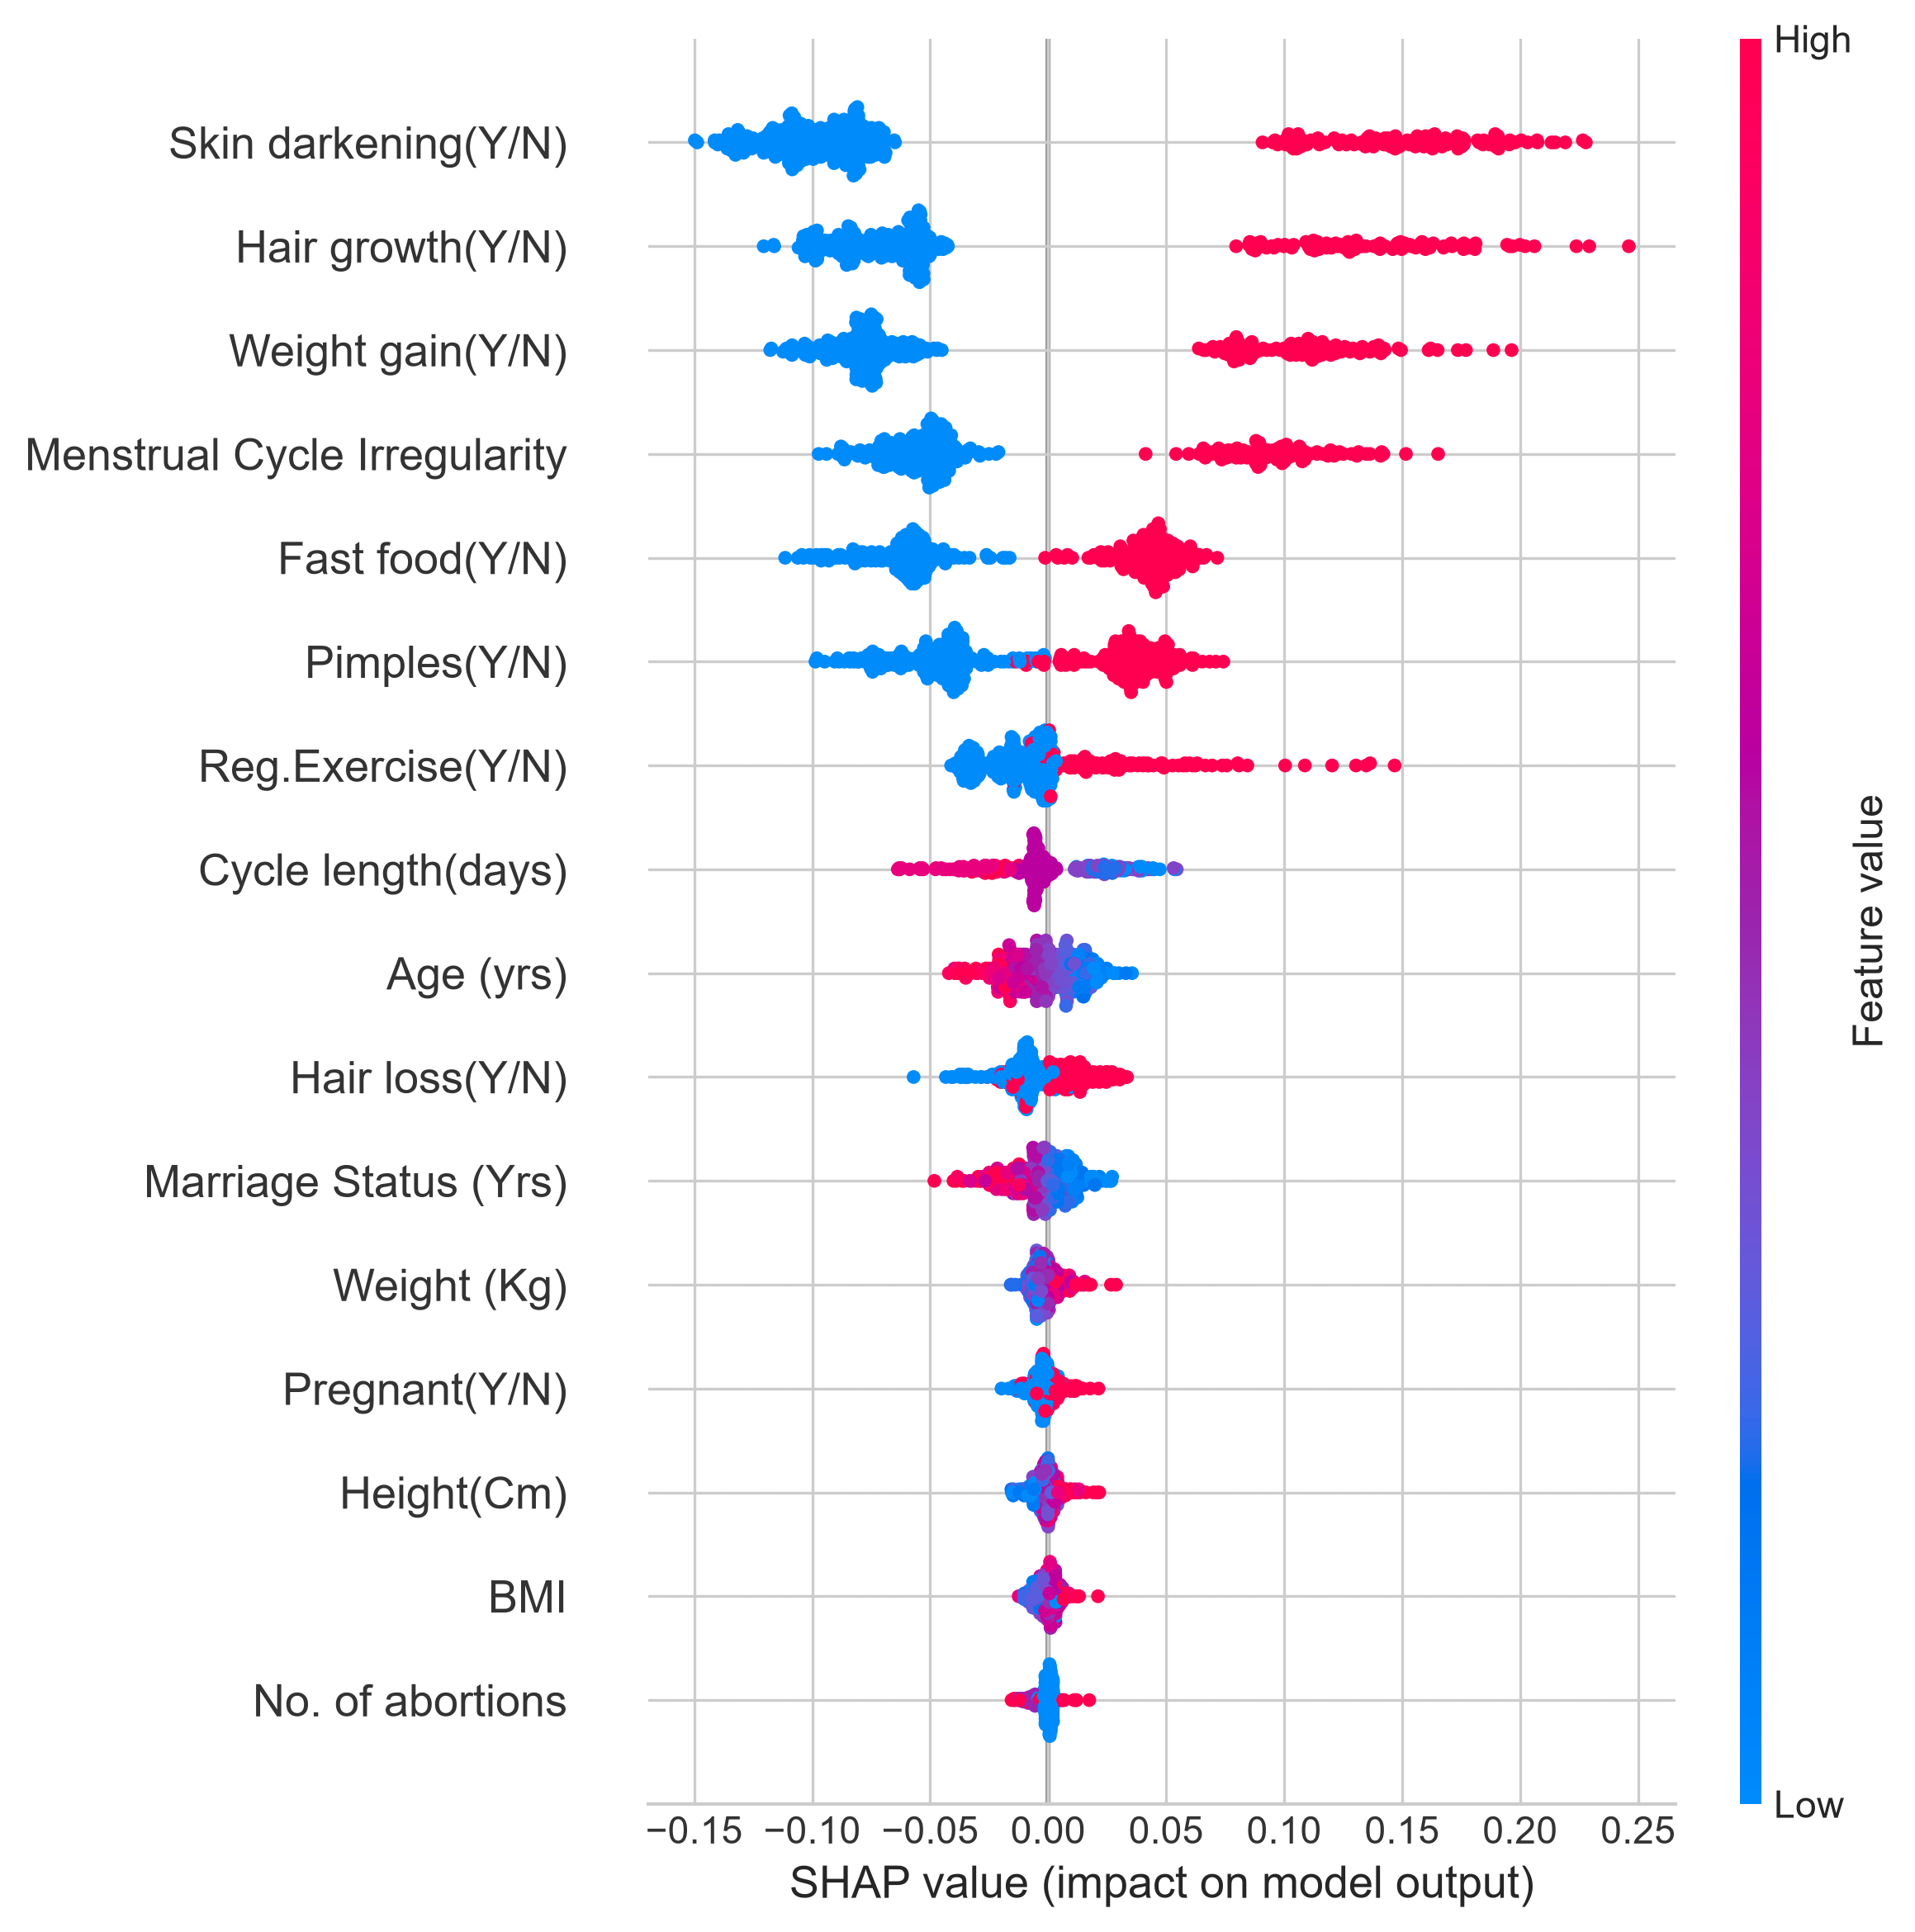

In [12]:
preprocessor = final_pipeline.named_steps['preprocessor']
classifier = final_pipeline.named_steps['classifier']

X_train_trans = preprocessor.transform(X_train)

feature_names = [
    'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Cycle length(days)', 'Marriage Status (Yrs)', 'No. of abortions',
    'Pregnant(Y/N)', 'Weight gain(Y/N)', 'Hair growth(Y/N)', 'Skin darkening(Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food(Y/N)', 'Reg.Exercise(Y/N)',
    'Menstrual Cycle Irregularity'
]

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_train_trans)

if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals_class1 = shap_values[:, :, 1]
else:
    shap_vals_class1 = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_class1, X_train_trans, feature_names=feature_names, show=True)


## 9. Generated Publication Figures

The complete suite of Phase 3 evaluation figures has been generated in `reports/figures/`:
* `07_hyperparameter_tuning_comparison.png`
* `08_threshold_performance_curve.png`
* `09_calibration_curves.png`
* `10_final_roc_pr_curves.png`
* `11_final_test_confusion_matrices.png`
* `12_shap_feature_importance_summary.png`
* `13_shap_local_explanations.png`


In [13]:
fig_files = [
    '07_hyperparameter_tuning_comparison.png',
    '08_threshold_performance_curve.png',
    '09_calibration_curves.png',
    '10_final_roc_pr_curves.png',
    '11_final_test_confusion_matrices.png',
    '12_shap_feature_importance_summary.png',
    '13_shap_local_explanations.png'
]

for f in fig_files:
    p = os.path.join(FIGURES_DIR, f)
    print(f"Verified artifact: {p} (Size: {os.path.getsize(p)/1024:.1f} KB)")


Verified artifact: c:\Users\hp\Desktop\Ovasense-ML\reports\figures\07_hyperparameter_tuning_comparison.png (Size: 141.9 KB)
Verified artifact: c:\Users\hp\Desktop\Ovasense-ML\reports\figures\08_threshold_performance_curve.png (Size: 529.9 KB)
Verified artifact: c:\Users\hp\Desktop\Ovasense-ML\reports\figures\09_calibration_curves.png (Size: 546.1 KB)
Verified artifact: c:\Users\hp\Desktop\Ovasense-ML\reports\figures\10_final_roc_pr_curves.png (Size: 326.6 KB)
Verified artifact: c:\Users\hp\Desktop\Ovasense-ML\reports\figures\11_final_test_confusion_matrices.png (Size: 169.7 KB)
Verified artifact: c:\Users\hp\Desktop\Ovasense-ML\reports\figures\12_shap_feature_importance_summary.png (Size: 349.5 KB)
Verified artifact: c:\Users\hp\Desktop\Ovasense-ML\reports\figures\13_shap_local_explanations.png (Size: 359.1 KB)


## 10. Clinical Safety Disclaimer & Model Configuration

```json
{
  "warning": "CRITICAL: OvaSense is strictly an early risk-screening and educational tool based on non-invasive questionnaires. It does NOT diagnose PCOS, does NOT replace formal Rotterdam criteria evaluation (ultrasound follicle assessment / serum biochemical assays), and does NOT substitute for consultation with a qualified medical professional."
}
```


In [14]:
with open(os.path.join(MODELS_DIR, 'ovasense_model_config.json'), 'r') as f:
    config_dict = json.load(f)

print(json.dumps(config_dict, indent=2))


{
  "model_name": "OvaSense Extra Trees (Screening Tuned)",
  "model_version": "1.0.0-phase3",
  "date_created": "2026-08-31 18:04:59",
  "training_metadata": {
    "training_samples": 432,
    "test_samples": 109,
    "positive_prevalence_train": 0.3263888888888889,
    "positive_prevalence_test": 0.3302752293577982,
    "cv_strategy": "5-Fold StratifiedKFold(shuffle=True, random_state=42)",
    "random_state": 42
  },
  "selected_hyperparameters": {
    "n_estimators": 150,
    "max_depth": 7,
    "min_samples_split": 5,
    "min_samples_leaf": 4,
    "max_features": "log2",
    "class_weight": "balanced_subsample"
  },
  "feature_list": [
    " Age (yrs)",
    "Weight (Kg)",
    "Height(Cm) ",
    "BMI",
    "Cycle(R/I)",
    "Cycle length(days)",
    "Marraige Status (Yrs)",
    "Pregnant(Y/N)",
    "No. of aborptions",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"